In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv('student_data_svm.csv')
data = data.dropna()
math = np.array(data['math_test'])
lang = np.array(data['lang_test'])
X_raw = np.column_stack((math, lang))
mean = np.mean(X_raw, axis=0)
std = np.std(X_raw, axis=0)
X = (X_raw - mean) / std
y = np.array(data['got_in'])
learning_rate = 0.001
w_first = np.array([0, 0])
b_first = 0
n = len(X)
lam = 0.00001


def score(w: np.array, b: float, X: np.array) -> float:
    return np.dot(X, w) - b


def hinge_loss(w: np.array, b: float, X: np.array, y: np.array) -> float:
    scores = X @ w - b
    margins = 1 - y * scores
    hinge_losses = np.maximum(0, margins)
    return np.mean(hinge_losses)


def w_length(w):
    return np.sqrt(np.sum(np.square(w)))


def cost_function(w: np.array, b: float, n: int, lam: float, X: np.array, y: np.array):
    return lam * w_length(w) ** 2 + hinge_loss(w, b, X, y)


def gradient(w: np.array, b: float, lam: float, n: int, X: np.array, y: np.array):
    w_grad_sum = np.zeros(w.shape)
    b_grad_sum = 0.0
    for i in range(len(X)):
        if y[i] * score(w, b, X[i]) >= 1:
            w_grad_sum += 2 * lam * w
            b_grad_sum += 0
        else:
            w_grad_sum += 2 * lam * w - y[i] * X[i]
            b_grad_sum += y[i]
    return w_grad_sum / n, b_grad_sum / n


def gradient_step(w: np.array, w_grad: np.array, b: np.array, b_grad: np.array, learning_rate: float):
    w_new = w - learning_rate * w_grad
    b_new = b - learning_rate * b_grad
    return w_new, b_new


def gradient_algorithm(w: np.array, b: np.array, X: np.array, y: np.array, learning_rate: float, lam: float):
    cost_function_old = 0
    cost_function_delta = np.inf
    while cost_function_delta > 0.000001:
        w_grad, b_grad = gradient(w, b, lam, n, X, y)
        w_new, b_new = gradient_step(w, w_grad, b, b_grad, learning_rate )
        cost_function_new = cost_function(w_new, b_new, n, lam, X, y)
        cost_function_delta = abs(cost_function_new - cost_function_old)
        cost_function_old = cost_function_new
        w = w_new
        b = b_new
    return w_new, b_new
    
#print(score(w_first, b_first, X))
#print(gradient(w_first, b_first, lam, n, X, y))
model = gradient_algorithm(w_first, b_first, X, y, learning_rate, lam)
print(model)

(array([0.98811355, 1.16598395]), np.float64(-0.05500999999999617))


Drawing for [0.98811355 1.16598395] and -0.05500999999999617


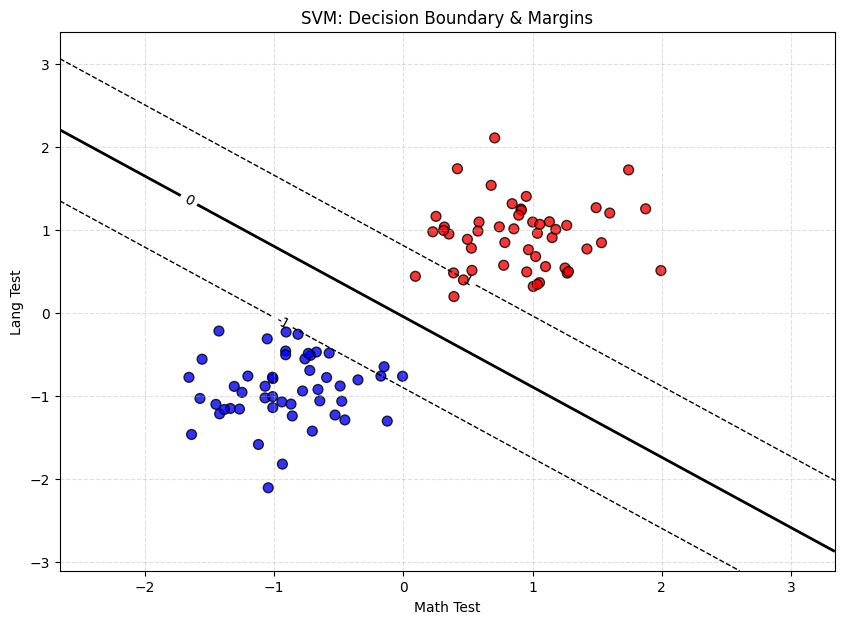

In [87]:
import numpy as np
import matplotlib.pyplot as plt

w_final, b_final = model

print(f"Drawing for {w_final} and {b_final}")
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1.5
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5),
                     np.arange(y_min, y_max, 0.5))

Z = (w_final[0] * xx + w_final[1] * yy) - b_final

plt.figure(figsize=(10, 7))

contours = plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', 
                       linestyles=['dashed', 'solid', 'dashed'], linewidths=[1, 2, 1])

plt.clabel(contours, inline=True, fontsize=10, fmt='%1.0f')

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', s=50, edgecolors='k', alpha=0.8)

plt.xlabel('Math Test')
plt.ylabel('Lang Test')
plt.title('SVM: Decision Boundary & Margins')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()